# Clustering basado en Densidad

Autores: Pablo Hernández Cámara (pablo.hernandez-camara@uv.es) y Pedro Ramón Ventura Gómez (pventura@march-am.com)



En este notebook veremos cómo superar las limitaciones geométricas de K-means utilizando DBSCAN y Mean Shifts, algoritmos que agrupan puntos basándose en su conectividad y densidad, lo cual es fundamental para encontrar patrones complejos.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.datasets import make_moons, make_blobs, fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

plt.style.use('seaborn-v0_8')

## El fallo de K-means



Antes de empezar con la densidad, vamos a demostrar por qué K-means no es la herramienta universal.

Primero necesitamos los datos, vamos a generarlos.

In [ ]:
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)
print(X.shape)

(300, 2)


**Ejercicio: Representa los datos. ¿Cuales dirian que van a ser los primeros puntos en unirse?**

Primero, vamos a aplicar k-means a ver que nos da.

**Ejercicio: Aplica k-means en estos datos.**

## DBSCAN a mano

DBSCAN no busca centros, busca "Core Points". Un punto es "Core" si tiene suficientes vecinos en un radio determinado ($\epsilon$). Vamos a implementar la parte más importante: identificar qué puntos son "Core" (núcleo).

In [ ]:
def get_neighbors(X, point_idx, eps):
    distances = np.linalg.norm(X - X[point_idx], axis=1)
    return np.where(distances <= eps)[0]

**Ejercicio: Prueba esta función para un punto aleatorio y un eps=0.3. ¿Cuantos vecinos hay dentro de este radio para este punto?**

Vamos a visualizarlo.

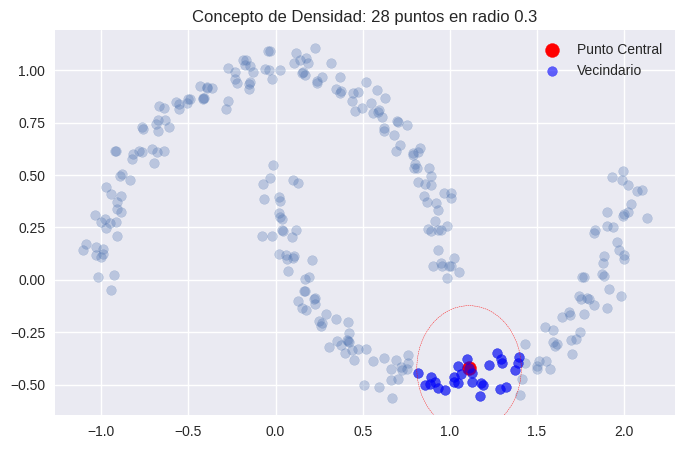

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], alpha=0.3)
plt.scatter(X[idx, 0], X[idx, 1], c='red', s=100, label='Punto Central')
plt.scatter(X[neighbors, 0], X[neighbors, 1], c='blue', alpha=0.6, label='Vecindario')
circle = plt.Circle(X[idx], eps, color='red', fill=False, linestyle='--')
plt.gca().add_artist(circle)
plt.title(f"Concepto de Densidad: {len(neighbors)} puntos en radio {eps}")
plt.legend()
plt.show()

Ahora definimos la función que detecta el tipo de punto según si tiene bastantes vecinos cerca o no.

In [ ]:
def identificar_tipos_puntos(X, eps, min_samples):
    n_samples = X.shape[0]
    tipos = np.full(n_samples, "Ruido", dtype='<U10') # Por defecto todos son ruido

    for i in range(n_samples):
        vecinos = get_neighbors(X, i, eps)
        if len(vecinos) >= min_samples:
            tipos[i] = "Core"

    return tipos

**Ejercicio: Ejecuta las funciones previas sobre los datos generados. Empieza probando con eps = 0.5 y min_pts = 10.**

## DBSCAN con Scikit-Learn

Ahora usaremos la versión de sklearn. El reto de DBSCAN es entender cómo interactúan Epsilon ($\epsilon$) y Min_Samples.

**Ejercicio: Aplica DBSCAN con eps=0.2 y min_samples=20. ¿Cuantos clusters obtienes? ¿Y cuantos puntos son considerados ruido? Visualizalo.**

**Ejercicio: Prueba distintas configuraciones de eps y n_points. ¿Cuales consideras que te dan un buen resultado? ¿Como depende de cada uno de estos parametros? Prueba a fijar uno y variar el otro.**

## DBSCAN en datos reales

In [ ]:
raw_data = fetch_openml(name='credit-g', version=1, as_frame=True)
X_credit = raw_data.data.select_dtypes(include=[np.number])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_credit)
print(X_scaled.shape)

(1000, 7)


**Ejercicio: Aplica DBSCAN con eps=2.0 y min_samples=10.**

**Ejercicio: Siendo el banco, ¿que es lo que nos interesa?**

**Ejercicio: Visualizalos en el espacio de PCA 2D.**

**Ejercicio: Prueba a cambiar los valores para ser más robusto detectando las anomalias.**

## Mean Shift

En esta segunda parte del notebook probaremos el otro algoritmo basado en densidades, Mean Shit.

Mean Shift es un algoritmo de ventana deslizante. Si DBSCAN es "conectividad", Mean Shift es "atracción". Los puntos se mueven hacia el centro de masa de su densidad local.

La clave es el "Mean Shift Vector", que es la diferencia entre el centro de nuestra ventana y la media de los puntos que caen dentro de ella.

In [ ]:
def mean_shift_step(X, center, bandwidth):
    # 1. Encontrar puntos dentro del radio (bandwidth)
    distancias = np.linalg.norm(X - center, axis=1)
    puntos_dentro = X[distancias <= bandwidth]

    # 2. Calcular la nueva media de esos puntos
    if len(puntos_dentro) > 0:
        new_center = np.mean(puntos_dentro, axis=0)
    else:
        new_center = center

    return new_center

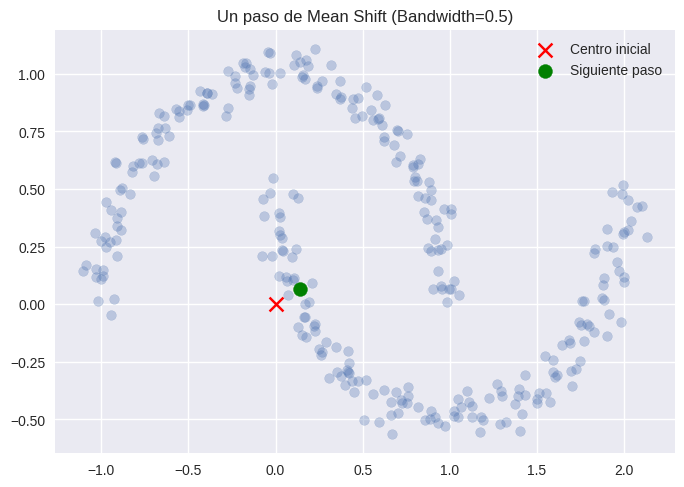

In [ ]:
center_init = np.array([0, 0])
bw = 0.5
next_center = mean_shift_step(X, center_init, bw)

plt.scatter(X[:, 0], X[:, 1], alpha=0.3)
plt.scatter(center_init[0], center_init[1], c='red', marker='x', s=100, label='Centro inicial')
plt.scatter(next_center[0], next_center[1], c='green', marker='o', s=100, label='Siguiente paso')
plt.title(f"Un paso de Mean Shift (Bandwidth={bw})")
plt.legend()
plt.show()

Bandwidth estimado automáticamente: 0.6712


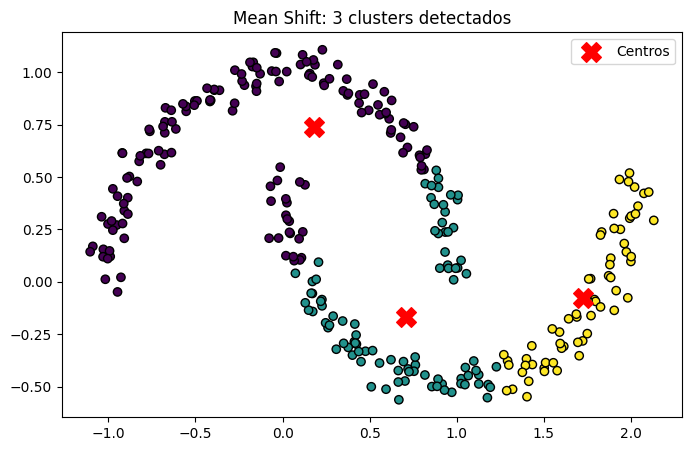

In [ ]:
from sklearn.cluster import MeanShift, estimate_bandwidth

# 1. Estimación automática del bandwidth
# quantile=0.2 significa que miramos el 20% de los vecinos para estimar el radio
bw_estimado = estimate_bandwidth(X, quantile=0.2, n_samples=len(X))
print(f"Bandwidth estimado automáticamente: {bw_estimado:.4f}")

# 2. Aplicar el modelo
ms = MeanShift(bandwidth=bw_estimado, bin_seeding=True)
ms_labels = ms.fit_predict(X)
cluster_centers = ms.cluster_centers_

# 3. Visualización
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=ms_labels, cmap='viridis', edgecolors='k')
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], c='red', marker='X', s=200, label='Centros')
plt.title(f"Mean Shift: {len(np.unique(ms_labels))} clusters detectados")
plt.legend()1
plt.show()

Vamos a aplicarlo a otros datos.

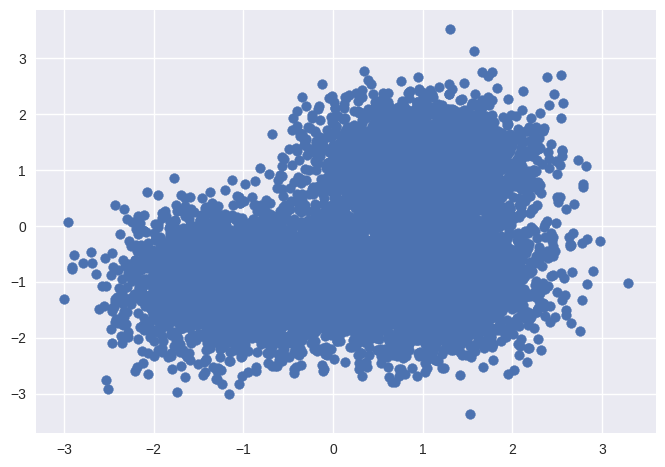

In [ ]:
centers = [[1, 1], [-1, -1], [1, -1]]
X, _ = make_blobs(n_samples=10000, centers=centers, cluster_std=0.6)

plt.scatter(X[:,0], X[:,1])
plt.show()

**Ejercicio: Aplica MeanShift. ¿Cuantos clusters encuentra? Representalos.**